In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [11]:
data= pd.read_csv("Sleep_Data_Sampled.csv")
df= pd.DataFrame(data)
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,35,Doctor,6.65,7,50,7,Normal Weight,120/80,71,7100,Healthy
1,2,Male,42,Teacher,6.90,8,52,4,Normal,135/90,66,7000,Healthy
2,3,Male,34,Software Engineer,6.95,7,66,6,Overweight,126/83,74,6100,Healthy
3,4,Male,32,Doctor,6.90,6,52,7,Normal,120/80,71,6500,Healthy
4,5,Male,37,Lawyer,6.85,7,60,6,Normal,125/80,71,6500,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14996,14997,Female,59,Nurse,8.00,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14997,14998,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14998,14999,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [12]:
print(df.corr(numeric_only=True)['Quality of Sleep'].sort_values(ascending=False))


Quality of Sleep           1.000000
Sleep Duration             0.871070
Age                        0.382186
Physical Activity Level    0.381601
Daily Steps                0.188875
Person ID                 -0.423943
Heart Rate                -0.451876
Stress Level              -0.785485
Name: Quality of Sleep, dtype: float64


In [13]:
X = df[[
    'Sleep Duration',
    'Age',
    'Physical Activity Level',
    'Daily Steps',
    'Gender',
    'Occupation'
]]

y = df['Quality of Sleep']
pd.get_dummies(X, drop_first=False)

,Sleep Duration,Age,Physical Activity Level,Daily Steps,Gender_Female,Gender_Male,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,6.65,35,50,7100,False,True,False,True,False,False,False,False,False,False,False,False,False
1,6.90,42,52,7000,False,True,False,False,False,False,False,False,False,False,False,False,True
2,6.95,34,66,6100,False,True,False,False,False,False,False,False,False,False,False,True,False
3,6.90,32,52,6500,False,True,False,True,False,False,False,False,False,False,False,False,False
4,6.85,37,60,6500,False,True,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,8.10,59,75,7000,True,False,False,False,False,False,False,True,False,False,False,False,False
14996,8.00,59,75,7000,True,False,False,False,False,False,False,True,False,False,False,False,False
14997,8.10,59,75,7000,True,False,False,False,False,False,False,True,False,False,False,False,False
14998,8.10,59,75,7000,True,False,False,False,False,False,False,True,False,False,False,False,False


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train columns:", X_train.columns.tolist())

X_train columns: ['Sleep Duration', 'Age', 'Physical Activity Level', 'Daily Steps', 'Gender', 'Occupation']


In [ ]:
#Define columns
categorical = ['Gender', 'Occupation']
numerical = ['Sleep Duration', 'Age', 'Physical Activity Level', 'Daily Steps']

#Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical),
    ('num', 'passthrough', numerical)
])

#Pipeline
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

#Training
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender', 'Occupation']),
                                                 ('num', 'passthrough',
                                                  ['Sleep Duration', 'Age',
                                                   'Physical Activity Level',
                                                   'Daily Steps'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [16]:
y_pred = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2_score(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

print("MAE:", mae)


R²: 0.9848242655676522
RMSE: 0.12949739788220194
MAE: 0.02991150830778416


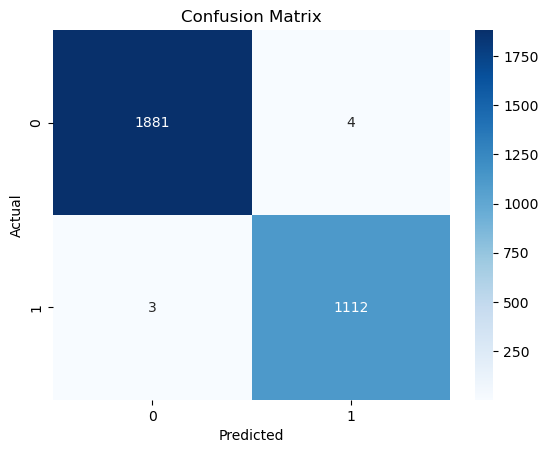

In [ ]:
#Confusion matrix- convert to classification problem
def sleep_category(x):
    if x >= 7:
        return "Good"
    elif x >= 4:
        return "Medium"
    else:
        return "Poor"

df["Sleep_Category"] = df["Quality of Sleep"].apply(sleep_category)

X = df.drop(["Quality of Sleep", "Sleep_Category"], axis=1)
y = df["Sleep_Category"]

#Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Testing the model (sleep quality is on a scale of 4-9)

sample_student = pd.DataFrame([{
    'Sleep Duration': 3,
    'Age': 34,
    'Physical Activity Level': 66,
    'Daily Steps': 1000,
    'Gender': "Female",
    'Occupation' : "Software Engineer"
}])

predicted_score = pipeline.predict(sample_student)

print("Predicted Sleep Quality Score:", predicted_score[0])

Predicted Sleep Quality Score: 4.04
